# 🏠 Irish Rental Crisis — Analysis & Prediction Platform
## Notebook 04: Feature Engineering & Preprocessing

---

This notebook takes the cleaned quarterly rent dataset from Notebook 02 and prepares it for the machine learning model in Notebook 06.

The raw dataset has 7 columns — most of them strings. A model can't learn from strings. This notebook transforms everything into numeric features, engineers some new ones based on what we found in the EDA, handles outliers, and exports a model-ready dataset.

**Input:** `rent_quarterly_clean.csv` — 210,865 rows  
**Output:** `rent_model_ready.csv` — clean, numeric, model-ready

---

| Step | What we do |
|------|-----------|
| 1 | Drop redundant columns |
| 2 | Handle outliers and log-transform the target |
| 3 | Engineer new features from EDA insights |
| 4 | Encode categorical columns |
| 5 | Scale numeric features |
| 6 | Drop weak and redundant features |
| 7 | Final validation and export |

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('ready.')

ready.


In [2]:
df = pd.read_csv('/content/rent_quarterly_clean.csv')

print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')
print()
df.head()

Shape  : (210865, 7)
Columns: ['Quarter', 'Bedrooms', 'PropertyType', 'Location', 'Value', 'Year', 'Q_Num']



,Quarter,Bedrooms,PropertyType,Location,Value,Year,Q_Num
0,2015Q1,All bedrooms,All property types,Carlow,595.48,2015,1
1,2015Q1,All bedrooms,All property types,Carlow Town,621.30,2015,1
2,2015Q1,All bedrooms,All property types,"Graiguecullen, Carlow",546.54,2015,1
3,2015Q1,All bedrooms,All property types,"Tullow, Carlow",569.47,2015,1
4,2015Q1,All bedrooms,All property types,Cavan,456.46,2015,1


In [3]:
print('Dtypes:')
print(df.dtypes)
print()
print('Nulls:')
print(df.isnull().sum())
print()
print('Value stats:')
print(df['Value'].describe().round(2))

Dtypes:
Quarter          object
Bedrooms         object
PropertyType     object
Location         object
Value           float64
Year              int64
Q_Num             int64
dtype: object

Nulls:
Quarter         0
Bedrooms        0
PropertyType    0
Location        0
Value           0
Year            0
Q_Num           0
dtype: int64

Value stats:
count    210865.00
mean       1159.79
std         518.62
min         233.67
25%         748.24
50%        1073.57
75%        1477.54
max        6522.48
Name: Value, dtype: float64


---
## Step 1 — Drop redundant columns

`Quarter` is a string like "2019Q3". We already have `Year` and `Q_Num` which capture the same information — no point keeping it.

In [4]:
df = df.drop(columns=['Quarter'])

print(f'Columns: {list(df.columns)}')
print(f'Shape  : {df.shape}')

Columns: ['Bedrooms', 'PropertyType', 'Location', 'Value', 'Year', 'Q_Num']
Shape  : (210865, 6)


---
## Step 2 — Handle outliers and log-transform the target

Monthly rent is right-skewed with some extreme high values. We cap outliers using IQR and log-transform the target to make it more normally distributed — this helps the model learn better.

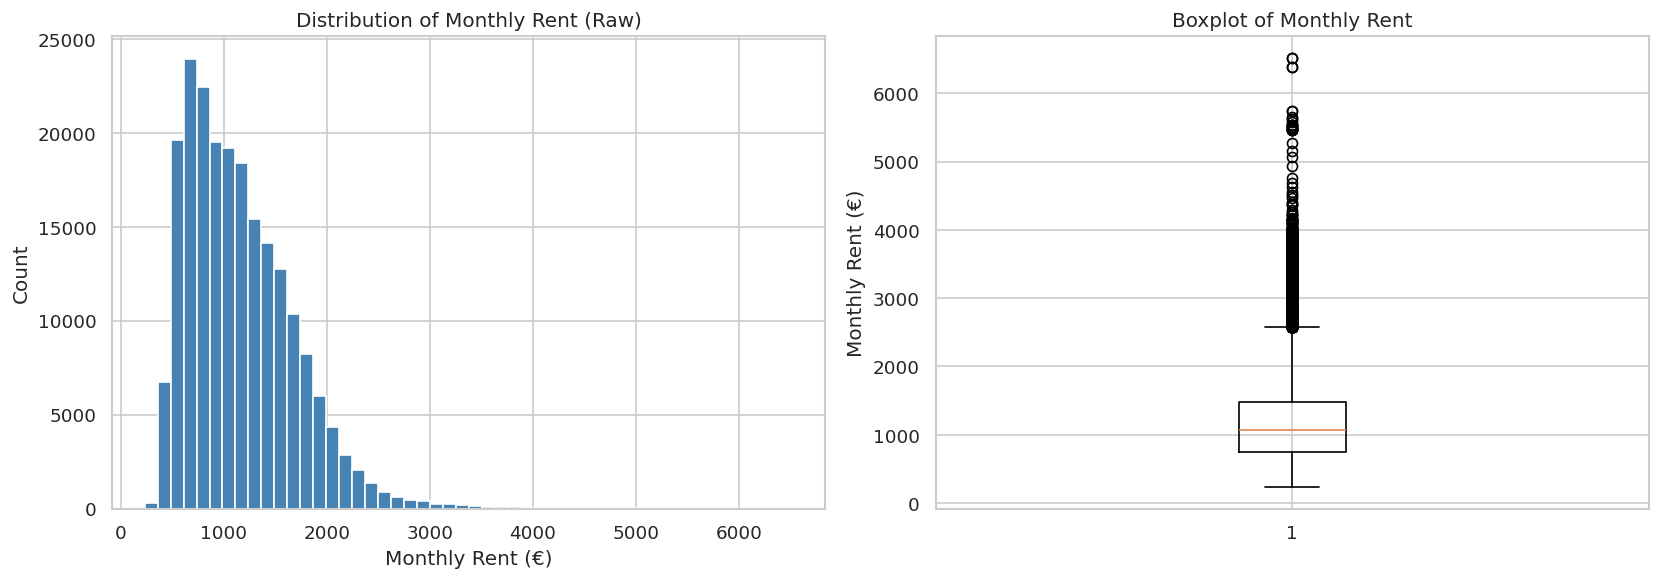

Min  : €234
Max  : €6522
Mean : €1160
Std  : €519


In [5]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Value'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Monthly Rent (Raw)')
plt.xlabel('Monthly Rent (€)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.boxplot(df['Value'], vert=True)
plt.title('Boxplot of Monthly Rent')
plt.ylabel('Monthly Rent (€)')

plt.tight_layout()
plt.show()

print(f'Min  : €{df["Value"].min():.0f}')
print(f'Max  : €{df["Value"].max():.0f}')
print(f'Mean : €{df["Value"].mean():.0f}')
print(f'Std  : €{df["Value"].std():.0f}')

In [6]:
Q1  = df['Value'].quantile(0.25)
Q3  = df['Value'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Value'] < lower) | (df['Value'] > upper)]

print(f'Q1         : €{Q1:.0f}')
print(f'Q3         : €{Q3:.0f}')
print(f'IQR        : €{IQR:.0f}')
print(f'Lower bound: €{lower:.0f}')
print(f'Upper bound: €{upper:.0f}')
print()
print(f'Outliers   : {len(outliers):,} rows ({len(outliers)/len(df)*100:.1f}%)')

Q1         : €748
Q3         : €1478
IQR        : €729
Lower bound: €-346
Upper bound: €2571

Outliers   : 2,859 rows (1.4%)


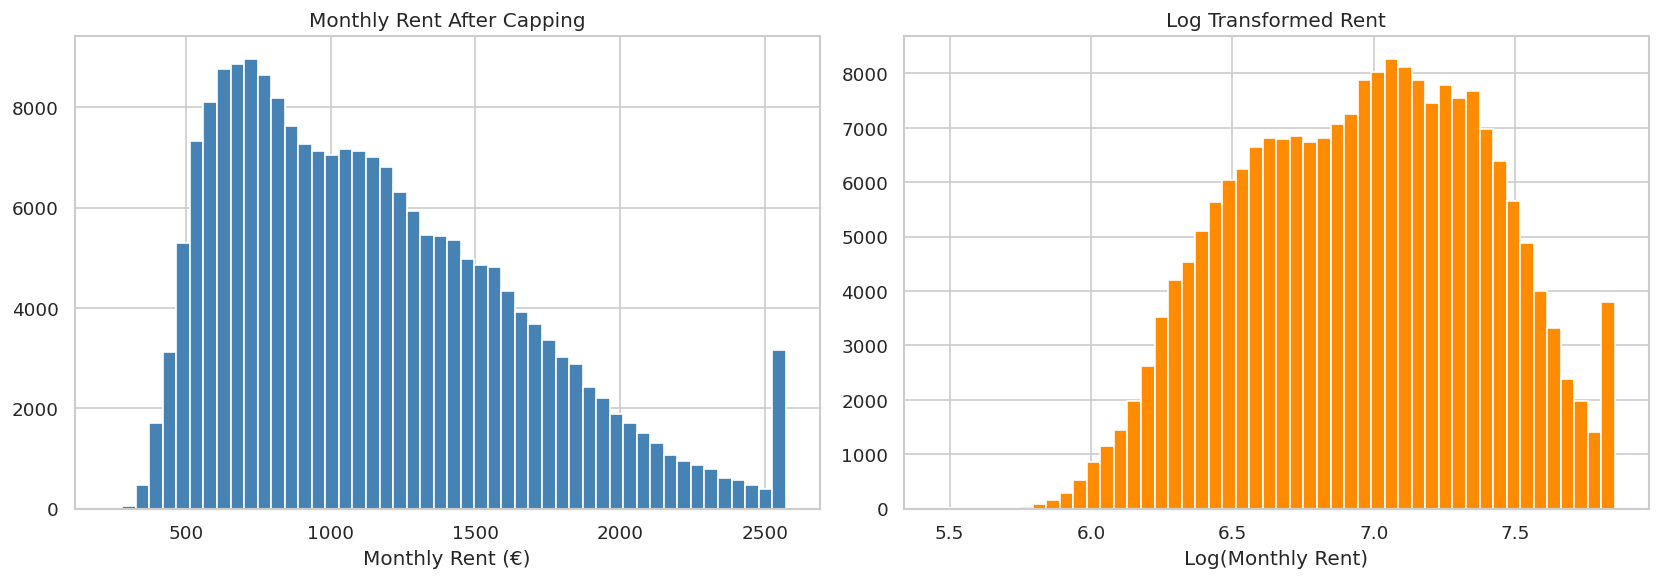

Value range after capping: €234 to €2571


In [7]:
# cap outliers — keep the rows, just clip the extreme values
df['Value'] = df['Value'].clip(lower=lower, upper=upper)

# log transform
df['Log_Value'] = np.log1p(df['Value'])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Value'], bins=50, color='steelblue', edgecolor='white')
plt.title('Monthly Rent After Capping')
plt.xlabel('Monthly Rent (€)')

plt.subplot(1, 2, 2)
plt.hist(df['Log_Value'], bins=50, color='darkorange', edgecolor='white')
plt.title('Log Transformed Rent')
plt.xlabel('Log(Monthly Rent)')

plt.tight_layout()
plt.show()

print(f'Value range after capping: €{df["Value"].min():.0f} to €{df["Value"].max():.0f}')

Log-transformed version is much closer to a normal distribution. We keep both columns — `Value` for human readability and `Log_Value` as the actual model target.

---
## Step 3 — Engineer new features

EDA gave us some clear signals. A few binary flags will help the model pick up patterns that raw columns can't express on their own.

In [8]:
# Is_Dublin — Dublin was a clear outlier in EDA, pays significantly more than rest of Ireland
df['Is_Dublin'] = df['Location'].str.contains('Dublin', case=False, na=False).astype(int)

print('Is_Dublin value counts:')
print(df['Is_Dublin'].value_counts())

Is_Dublin value counts:
Is_Dublin
0    131124
1     79741
Name: count, dtype: int64


In [9]:
# Rent_Era — groups years into market phases we identified in EDA
# Pre_Crisis 2015-2017 | Peak 2018-2019 | COVID 2020-2021 | Post_COVID 2022+
def assign_era(year):
    if year <= 2017:
        return 'Pre_Crisis'
    elif year <= 2019:
        return 'Peak'
    elif year <= 2021:
        return 'COVID'
    else:
        return 'Post_COVID'

df['Rent_Era'] = df['Year'].apply(assign_era)

print('Rent_Era value counts:')
print(df['Rent_Era'].value_counts())

Rent_Era value counts:
Rent_Era
Pre_Crisis    71398
Post_COVID    51268
Peak          45766
COVID         42433
Name: count, dtype: int64


---
## Step 4 — Encode categorical columns

- **Location** — target encoding (replace with mean rent per location — meaningful signal)
- **PropertyType** — one-hot encoding (small number of categories)
- **Bedrooms** — ordinal encoding (natural order exists)
- **Rent_Era** — ordinal encoding (chronological order)

Using target encoding for Location because label encoding assigns arbitrary alphabetical numbers which mean nothing to the model. Mean rent per location gives it a real signal — Dublin locations get high numbers, rural locations get low numbers.

In [10]:
# Location — target encoding
location_mean_rent = df.groupby('Location')['Value'].mean()
df['Location_Encoded'] = df['Location'].map(location_mean_rent)

print('Top 10 most expensive locations after encoding:')
print(df[['Location', 'Location_Encoded']].drop_duplicates()
      .sort_values('Location_Encoded', ascending=False).head(10))

Top 10 most expensive locations after encoding:
                         Location  Location_Encoded
101  Grand Canal Square, Dublin 2       2491.845270
214            Foxrock, Dublin 18       2324.893208
100    Grand Canal Dock, Dublin 2       2270.833396
82          Mount Merrion, Dublin       2167.066585
71                 Dalkey, Dublin       2152.247730
102        Hanover Quay, Dublin 2       2130.950746
74             Glenageary, Dublin       2116.853719
116         Ballsbridge, Dublin 4       2083.874825
95         Spencer Dock, Dublin 1       2071.055119
69              Blackrock, Dublin       2042.479758


In [11]:
# PropertyType — one-hot encoding
df = pd.get_dummies(df, columns=['PropertyType'], prefix='Type')

type_cols = [c for c in df.columns if c.startswith('Type_')]
df[type_cols] = df[type_cols].astype(int)

print('PropertyType columns created:')
print(type_cols)
print()
print('Value counts per type:')
for col in type_cols:
    print(f'  {col}: {df[col].sum():,}')

PropertyType columns created:
['Type_All property types', 'Type_Apartment', 'Type_Detached house', 'Type_Other flats', 'Type_Semi detached house', 'Type_Terrace house']

Value counts per type:
  Type_All property types: 79,728
  Type_Apartment: 50,560
  Type_Detached house: 14,271
  Type_Other flats: 10,033
  Type_Semi detached house: 30,603
  Type_Terrace house: 25,670


Dropping `Type_All property types` rows entirely — these are aggregate summary rows (All bedrooms × All property types), not real individual rental listings. Keeping them would mix aggregated figures with actual data and confuse the model.

In [12]:
# drop aggregate rows where PropertyType was 'All property types'
df = df[df['Type_All property types'] == 0].copy()
df = df.drop(columns=['Type_All property types'])

# update type_cols
type_cols = [c for c in df.columns if c.startswith('Type_')]

print(f'Rows after dropping aggregates: {df.shape[0]:,}')
print(f'Rows dropped: 79,728 aggregate rows removed')
print(f'Remaining type columns: {type_cols}')

Rows after dropping aggregates: 131,137
Rows dropped: 79,728 aggregate rows removed
Remaining type columns: ['Type_Apartment', 'Type_Detached house', 'Type_Other flats', 'Type_Semi detached house', 'Type_Terrace house']


In [13]:
# Bedrooms — ordinal encoding
# actual values in the data use different names than expected — checked and fixed
bedroom_order = {
    'One bed'        : 1,
    'Two bed'        : 2,
    'Three bed'      : 3,
    'Four plus bed'  : 4,
    '1 to 2 bed'     : 1.5,
    '1 to 3 bed'     : 2,
    'All bedrooms'   : 0
}

df['Bedrooms_Encoded'] = df['Bedrooms'].map(bedroom_order)

unmapped = df[df['Bedrooms_Encoded'].isnull()]['Bedrooms'].unique()
if len(unmapped) > 0:
    print(f'Unmapped: {unmapped}')
    df['Bedrooms_Encoded'] = df['Bedrooms_Encoded'].fillna(0)

print('Bedrooms encoding:')
print(df[['Bedrooms', 'Bedrooms_Encoded']].drop_duplicates().sort_values('Bedrooms_Encoded'))

Bedrooms encoding:
           Bedrooms  Bedrooms_Encoded
419    All bedrooms               0.0
1563        One bed               1.0
3595     1 to 2 bed               1.5
2065        Two bed               2.0
4528     1 to 3 bed               2.0
2797      Three bed               3.0
5581  Four plus bed               4.0


In [14]:
# Rent_Era — ordinal encoding
era_order = {
    'Pre_Crisis' : 0,
    'Peak'       : 1,
    'COVID'      : 2,
    'Post_COVID' : 3
}
df['Rent_Era_Encoded'] = df['Rent_Era'].map(era_order)

print('Rent_Era encoding:')
print(df[['Rent_Era', 'Rent_Era_Encoded']].drop_duplicates().sort_values('Rent_Era_Encoded'))

Rent_Era encoding:
          Rent_Era  Rent_Era_Encoded
419     Pre_Crisis                 0
71810         Peak                 1
117571       COVID                 2
159945  Post_COVID                 3


---
## Step 5 — Scale numeric features

Year ranges from 2015 to 2025 and Q_Num from 1 to 4. Scaling them to 0–1 so they don't dominate other features just because of their numeric range.

In [15]:
scaler = MinMaxScaler()
df[['Year_Scaled', 'Q_Num_Scaled']] = scaler.fit_transform(df[['Year', 'Q_Num']])

print('Year scaling:')
print(df[['Year', 'Year_Scaled']].drop_duplicates().sort_values('Year'))
print()
print('Q_Num scaling:')
print(df[['Q_Num', 'Q_Num_Scaled']].drop_duplicates().sort_values('Q_Num'))

Year scaling:
        Year  Year_Scaled
419     2015          0.0
24279   2016          0.1
48137   2017          0.2
71810   2018          0.3
94882   2019          0.4
117571  2020          0.5
139637  2021          0.6
159945  2022          0.7
176849  2023          0.8
192377  2024          0.9
205658  2025          1.0

Q_Num scaling:
       Q_Num  Q_Num_Scaled
419        1      0.000000
6219       2      0.333333
12116      3      0.666667
18241      4      1.000000


---
## Step 6 — Check correlations and drop weak/redundant features

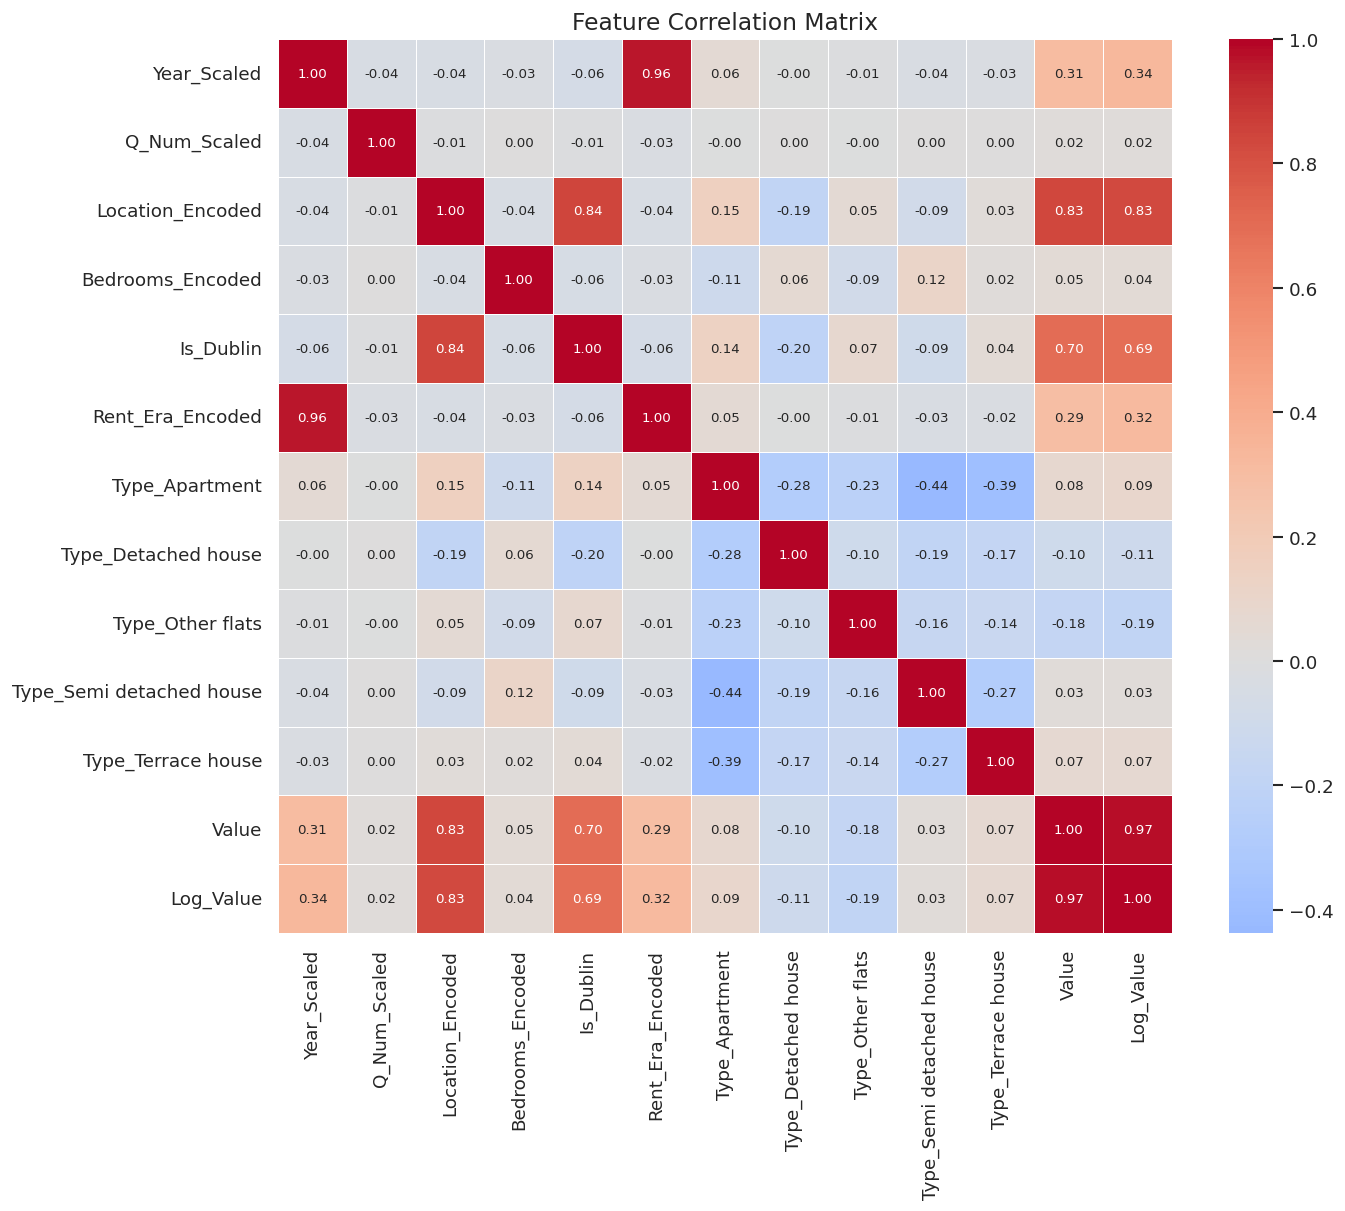

In [16]:
type_cols = [c for c in df.columns if c.startswith('Type_')]

feature_cols = (
    ['Year_Scaled', 'Q_Num_Scaled',
     'Location_Encoded', 'Bedrooms_Encoded',
     'Is_Dublin', 'Rent_Era_Encoded']
    + type_cols
    + ['Value', 'Log_Value']
)

df_model = df[feature_cols].copy()

# correlation heatmap
corr_matrix = df_model.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

Looking at the correlation matrix, two things stand out:

**Dropping `Rent_Era_Encoded`** — it has 0.96 correlation with `Year_Scaled`. That's too high, they're basically measuring the same thing. Rent_Era was engineered from Year so this makes sense in hindsight. Year_Scaled is more precise and continuous so we keep that and drop the era grouping.

**Keeping everything else** — even the weaker features like Q_Num_Scaled and Bedrooms_Encoded. Correlation with the target is low but XGBoost can pick up non-linear interactions that a simple correlation won't show. The EDA confirmed both matter in context.

In [17]:
# drop Rent_Era_Encoded — 0.96 correlation with Year_Scaled, completely redundant
df_model = df_model.drop(columns=['Rent_Era_Encoded'])

print(f'Final shape  : {df_model.shape}')
print(f'Final columns: {list(df_model.columns)}')
print(f'Nulls        : {df_model.isnull().sum().sum()}')

Final shape  : (131137, 12)
Final columns: ['Year_Scaled', 'Q_Num_Scaled', 'Location_Encoded', 'Bedrooms_Encoded', 'Is_Dublin', 'Type_Apartment', 'Type_Detached house', 'Type_Other flats', 'Type_Semi detached house', 'Type_Terrace house', 'Value', 'Log_Value']
Nulls        : 0


---
## Step 7 — Final validation and export

In [18]:
df_model.describe().round(3)

,Year_Scaled,Q_Num_Scaled,Location_Encoded,Bedrooms_Encoded,Is_Dublin,Type_Apartment,Type_Detached house,Type_Other flats,Type_Semi detached house,Type_Terrace house,Value,Log_Value
count,131137.000,131137.000,131137.000,131137.000,131137.000,131137.000,131137.000,131137.000,131137.000,131137.000,131137.000,131137.000
mean,0.410,0.497,1153.174,1.565,0.372,0.386,0.109,0.077,0.233,0.196,1144.048,6.951
std,0.285,0.371,411.882,1.153,0.483,0.487,0.311,0.266,0.423,0.397,493.036,0.433
min,0.000,0.000,477.574,0.000,0.000,0.000,0.000,0.000,0.000,0.000,233.670,5.458
25%,0.200,0.333,778.583,0.000,0.000,0.000,0.000,0.000,0.000,0.000,744.840,6.615
50%,0.400,0.333,1077.200,2.000,0.000,0.000,0.000,0.000,0.000,0.000,1059.230,6.966
75%,0.600,0.667,1479.720,2.000,1.000,1.000,0.000,0.000,0.000,0.000,1458.650,7.286
max,1.000,1.000,2491.845,4.000,1.000,1.000,1.000,1.000,1.000,1.000,2571.490,7.853


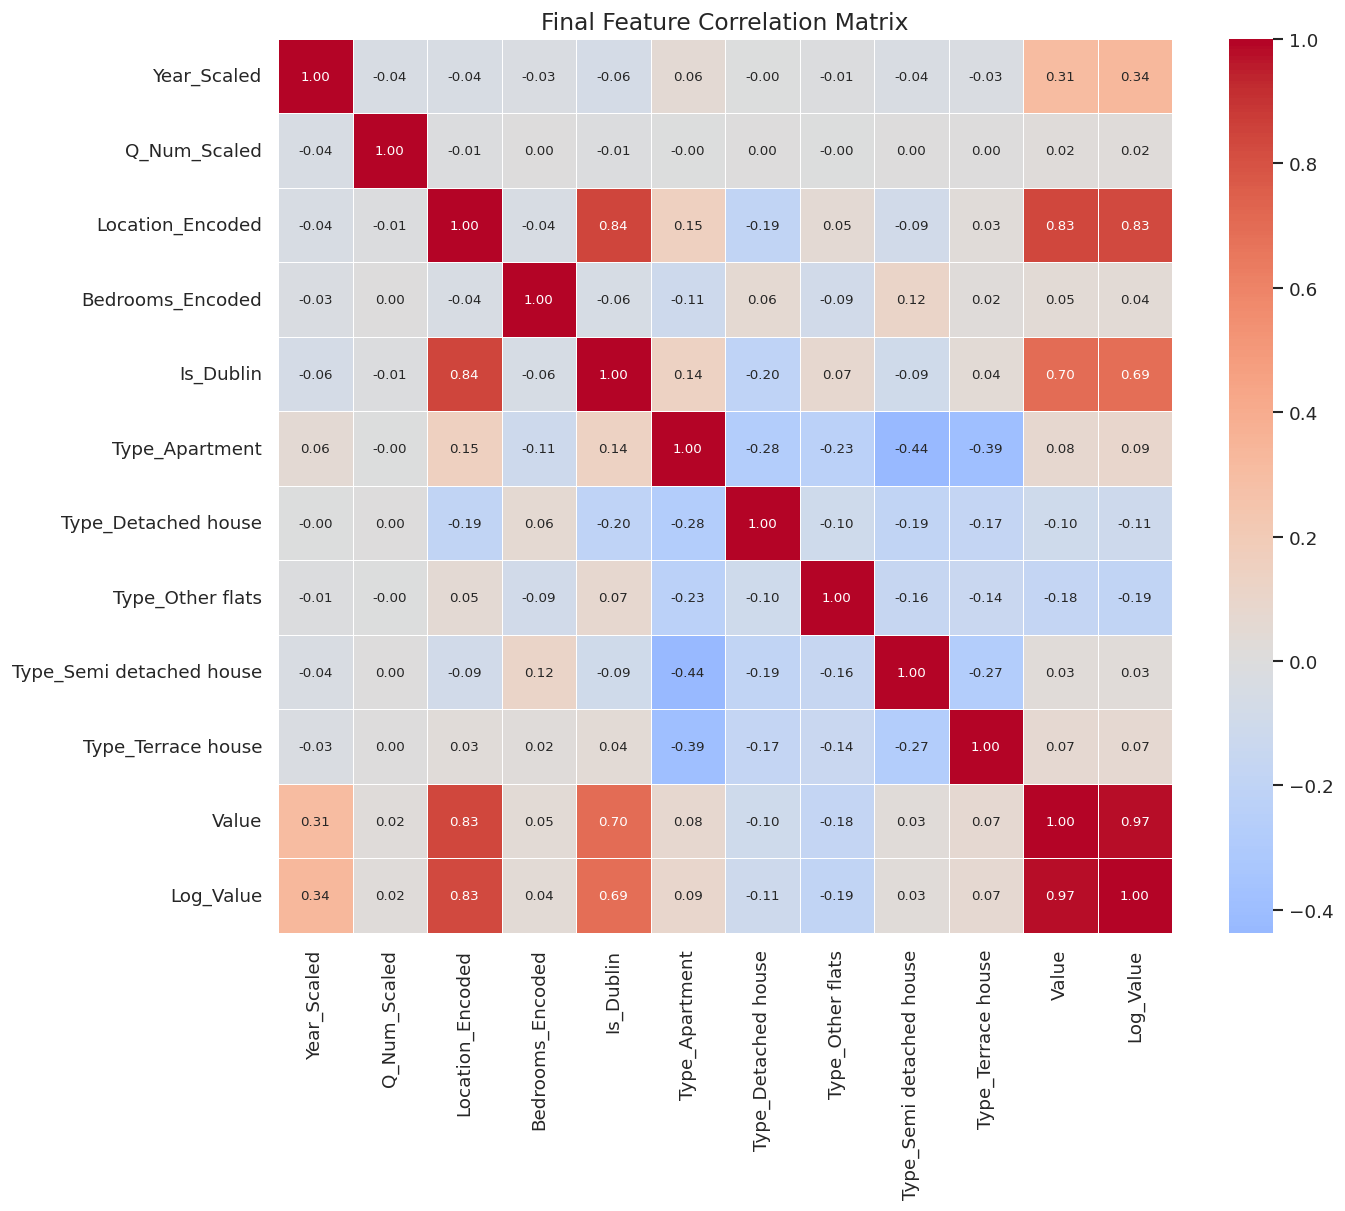

In [19]:
# final correlation heatmap with clean feature set
corr_final = df_model.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_final, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 8})
plt.title('Final Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# export
df_model.to_csv('/content/rent_model_ready.csv', index=False)

print('Export complete:')
print(f'  rent_model_ready.csv — {df_model.shape[0]:,} rows | {df_model.shape[1]} cols')
print()
print('Final features:')
for col in df_model.columns:
    print(f'  {col}')

# Download to local machine
from google.colab import files
files.download('/content/rent_model_ready.csv')

Export complete:
  rent_model_ready.csv — 131,137 rows | 12 cols

Final features:
  Year_Scaled
  Q_Num_Scaled
  Location_Encoded
  Bedrooms_Encoded
  Is_Dublin
  Type_Apartment
  Type_Detached house
  Type_Other flats
  Type_Semi detached house
  Type_Terrace house
  Value
  Log_Value


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:

print('NOTEBOOK 04 — FEATURE ENGINEERING COMPLETE')
print('─' * 105)
print()
print(f'Input  : rent_quarterly_clean.csv — 210,865 rows | 7 cols')
print(f'Output : rent_model_ready.csv     — {df_model.shape[0]:,} rows | {df_model.shape[1]} cols')
print()
print('Key decisions:')
print('  Dropped 79,728 aggregate rows (All property types / All bedrooms)')
print('  Used target encoding for Location — mean rent per location')
print('  Dropped Is_Commuter — low correlation, arbitrary boundary')
print('  Dropped Rent_Era_Encoded — 0.96 correlation with Year_Scaled, redundant')
print('  Kept weak features (Q_Num, Bedrooms) — XGBoost handles non-linear interactions')
print()
print('Next: Notebook 05 — SQL Warehouse & Business Queries')

NOTEBOOK 04 — FEATURE ENGINEERING COMPLETE
─────────────────────────────────────────────────────────────────────────────────────────────────────────

Input  : rent_quarterly_clean.csv — 210,865 rows | 7 cols
Output : rent_model_ready.csv     — 131,137 rows | 12 cols

Key decisions:
  Dropped 79,728 aggregate rows (All property types / All bedrooms)
  Used target encoding for Location — mean rent per location
  Dropped Is_Commuter — low correlation, arbitrary boundary
  Dropped Rent_Era_Encoded — 0.96 correlation with Year_Scaled, redundant
  Kept weak features (Q_Num, Bedrooms) — XGBoost handles non-linear interactions

Next: Notebook 05 — SQL Warehouse & Business Queries
